In [1]:
%matplotlib widget

In [2]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from astropy.modeling import models
from scipy.signal import convolve
from scipy.optimize import minimize
from astropy.convolution import Gaussian1DKernel
import scipy.integrate as integrate
from scipy.optimize import differential_evolution
import pandas as pd
import os

In [3]:
hdul = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_544/FORS2.2021-08-21T05_32_16.048/Reduced/Mrk-544_MAPPED_FLUX_SCI_LSS_U1.fits")
hdul.info()
image = hdul[0].data
image_error = hdul[1].data

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_544/FORS2.2021-08-21T05_32_16.048/Reduced/Mrk-544_MAPPED_FLUX_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     365   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        46   (2094, 964)   float32   


In [4]:
image_cut = image[55:155, 0:1890]
image_error_cut = image_error[55:155, 0:1890]

Text(0.5, 0, 'wavelenght')

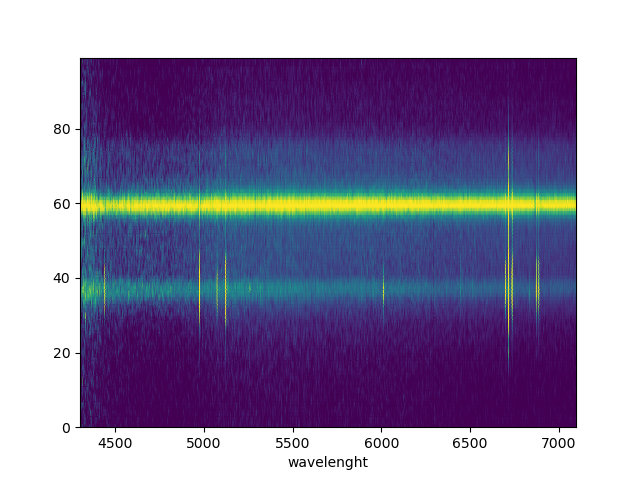

In [5]:
wv = np.arange(4300.74, 4300.74+1890*1.48, 1.48)
J, N = image_cut.data.shape
#x = np.arange(0, N, 1)
y = np.arange(0, J, 1)
arcsec_y = np.arange(-58*0.256, 42*0.256, 0.256)

x_grid, y_grid = np.meshgrid(wv, y)
plt.pcolormesh(x_grid, y_grid, image_cut, shading='gouraud', vmin = np.percentile(image_cut, 20), vmax = 0.16)
plt.xlabel('wavelenght')

In [6]:
z = 0.0238
l_HA = 6563 * (1+z)
l_HB = 4861 * (1+z) 
l_NII = 6583 * (1+z)
l_SII = 6717 * (1+z)
l_OIII = 5007 * (1+z)

Text(0.5, 1.0, 'H$\\alpha$')

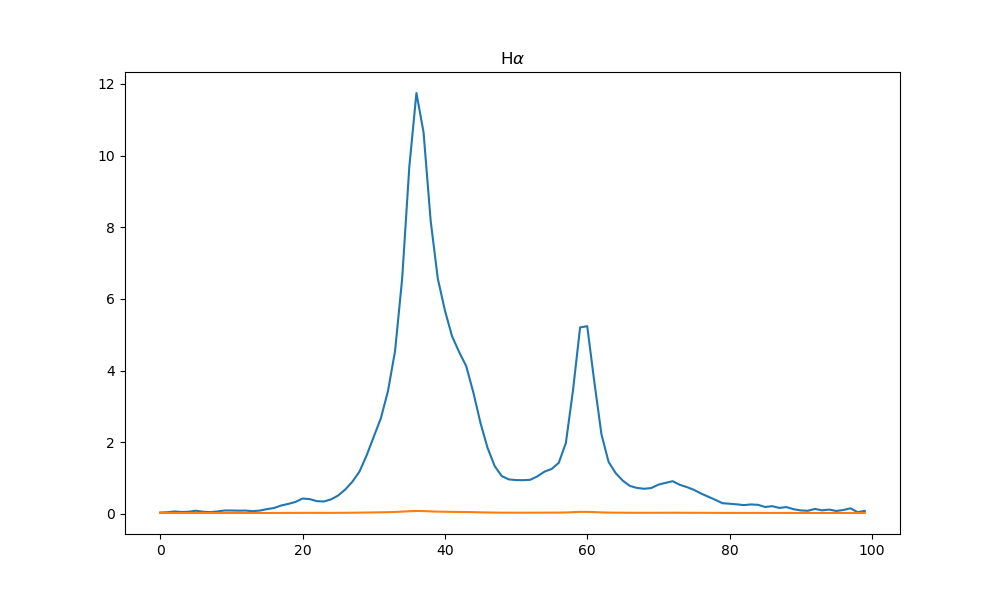

In [7]:
mask_HA = (wv > l_HA-8)*(wv < l_HA+8)
image_HA = image_cut[:, mask_HA]
image_error_HA = image_error_cut[:, mask_HA]
radial_profile_HA = np.sum(image_HA, axis = 1)
radial_profile_error_HA = np.sqrt(np.sum(image_error_HA**2, axis = 1))

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_HA)
plt.plot(x_axes, radial_profile_error_HA)
plt.title(r'H$\alpha$')
#fit_HA = pd.read_csv("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_544/FORS2.2021-08-21T05_32_16.048/Reduced/Fit_code/Halpha_fit.csv", index_col=0)

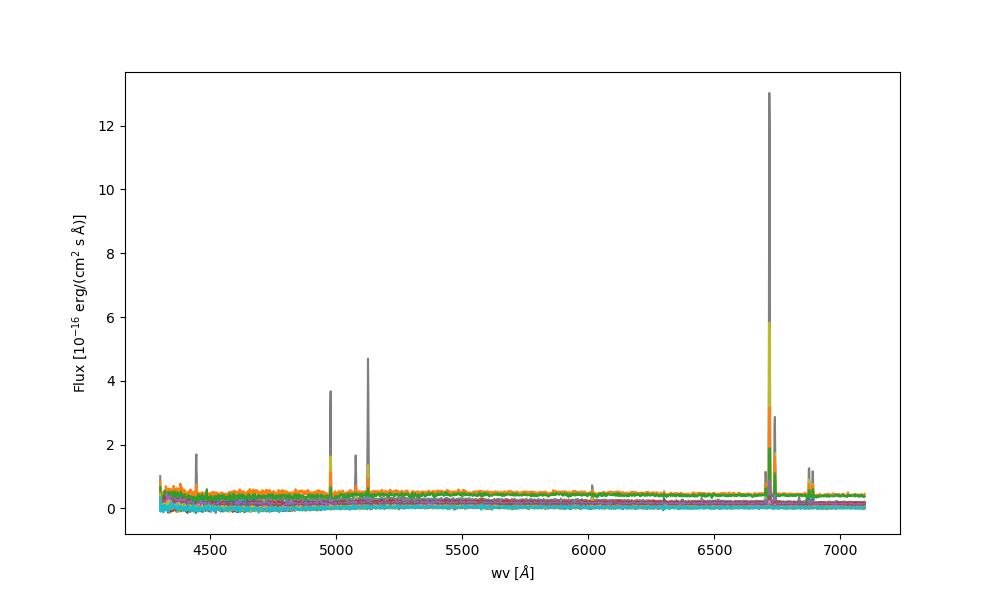

In [8]:
def extraction(x_axes, x_min, x_max, image_cut, image_error_cut):
    mask = (x_axes > x_min)*(x_axes < x_max)
    spectrum = np.sum(image_cut[mask, :], axis = 0)
    spectrum_err = np.sqrt(np.sum(image_error_cut[mask, :]**2, axis = 0))
    return spectrum, spectrum_err

os.makedirs('20ext', exist_ok=True)

spectra =  np.zeros((20, image_cut.shape[1]))
spectra_err = np.zeros((20, image_error_cut.shape[1]))
plt.figure(figsize=(10, 6))
for i in range(20):
    x_min = i * 5
    x_max = x_min + 5
    spectra[i], spectra_err[i] = extraction(x_axes, x_min, x_max, image_cut, image_error_cut)

    plt.plot(wv, spectra[i], label = f'spectrum {i+1}')
    plt.xlabel(r'wv [$\AA$]')
    plt.ylabel(r'Flux [$10^{-16}$ erg/(cm$^2$ s Å)]')
    
    spectrum_table = np.concatenate((wv.reshape(-1, 1), 
                                    spectra[i].reshape(-1, 1), spectra_err[i].reshape(-1, 1)), axis=1)
    filename = os.path.join('20ext', f'Spectrum_{i+1}.txt')  # Salva come spectrum_1.txt ... spectrum_20.txt
    np.savetxt(filename, spectrum_table)

## S/N continuum

In [9]:
mask_continuum_1 = (wv > 4500) * (wv < 4800)
mask_continuum_2 = (wv > 5300) * (wv < 5800)
mask_continuum_3 = (wv > 6400) * (wv < 6700)
# Liste per contenere i risultati
SNR = []
Signal = []
Noise = []
# Calcolo per ogni spettro
for i in range(20):  # Assumendo che peaks definisca il numero di spettri
    snr = []
    signal = []
    noise = []
    
    # Calcolo per continuum_1
    sig_1 = np.mean(spectra[i, mask_continuum_1])
    noise_1 = np.std(spectra[i, mask_continuum_1])
    snr_1 = sig_1 / noise_1
    
    # Calcolo per continuum_2  
    sig_2 = np.mean(spectra[i, mask_continuum_2])
    noise_2 = np.std(spectra[i, mask_continuum_2])
    snr_2 = sig_2 / noise_2
    
    # Calcolo per continuum_3
    sig_3 = np.mean(spectra[i, mask_continuum_3])
    noise_3 = np.std(spectra[i, mask_continuum_3])
    snr_3 = sig_3 / noise_3
    
    # Aggiunta ai risultati
    snr.extend([snr_1, snr_2, snr_3])
    signal.extend([sig_1, sig_2, sig_3])
    noise.extend([noise_1, noise_2, noise_3])
    
    SNR.append(snr)
    Signal.append(signal)
    Noise.append(noise)
    
# Conversione in array numpy e trasposizione
SNR_array = np.array(SNR).T  # Trasponi per avere continuum come righe
Signal_array = np.array(Signal).T
Noise_array = np.array(Noise).T

# Creazione del DataFrame
# Nomi delle colonne per ogni spettro
col_names = [f'Spectrum_{i+1}' for i in range(20)]
# Creazione di DataFrames separati per ogni metrica
df_snr = pd.DataFrame(SNR_array, 
                      columns=col_names,
                      index=['Continuum_1', 'Continuum_2', 'Continuum_3'])
df_signal = pd.DataFrame(Signal_array, 
                         columns=col_names,
                         index=['Continuum_1', 'Continuum_2', 'Continuum_3'])
df_noise = pd.DataFrame(Noise_array, 
                        columns=col_names,
                        index=['Continuum_1', 'Continuum_2', 'Continuum_3'])
# Combinazione in un unico DataFrame con MultiIndex per le colonne
df_combined = pd.concat([df_snr, df_signal, df_noise], 
                        keys=['SNR', 'Signal', 'Noise'], 
                        axis=1)
print("DataFrame SNR:")
print(df_snr)
print("\nDataFrame Signal:")
print(df_signal)
print("\nDataFrame Noise:")
print(df_noise)
print("\nDataFrame Combinato:")
print(df_combined)
# Salvataggio dei file
os.path.join('20ext', 'SNR_20ext_continuum.csv')
df_path_snr = os.path.join('20ext', 'SNR_20ext_continuum.csv')
df_path_signal = os.path.join('20ext', 'Signal_20ext_continuum.csv')
df_path_noise = os.path.join('20ext', 'Noise_20ext_continuum.csv')
df_path_combined = os.path.join('20ext', 'Combined_20ext_continuum.csv')
# Assicurati che la directory esista
os.makedirs('20ext', exist_ok=True)
df_snr.to_csv(df_path_snr, float_format='%.3f')
df_signal.to_csv(df_path_signal, float_format='%.3f')
df_noise.to_csv(df_path_noise, float_format='%.3f')
df_combined.to_csv(df_path_combined, float_format='%.3f')
print(f"\nFile salvati in:")
print(f"- {df_path_snr}")
print(f"- {df_path_signal}")
print(f"- {df_path_noise}")
print(f"- {df_path_combined}")

DataFrame SNR:
             Spectrum_1  Spectrum_2  Spectrum_3  Spectrum_4  Spectrum_5  \
Continuum_1   -0.856069   -0.840652   -0.627575   -0.207452    0.365156   
Continuum_2    1.537588    1.435217    1.989237    2.375714    3.091635   
Continuum_3    1.289338    1.496868    1.913122    2.263373    3.372251   

             Spectrum_6  Spectrum_7  Spectrum_8  Spectrum_9  Spectrum_10  \
Continuum_1    1.416273    3.882346    7.146522    3.627158     3.607161   
Continuum_2    4.305710    6.918836   10.389266    7.806136     8.473543   
Continuum_3    4.818946    7.234964   10.822370    7.385535     8.660587   

             Spectrum_11  Spectrum_12  Spectrum_13  Spectrum_14  Spectrum_15  \
Continuum_1     4.096031     9.565134     8.087325     3.831335     3.503744   
Continuum_2     8.797695    16.272673    15.891697     8.587073     7.226662   
Continuum_3    10.472348    20.912748    20.511694    10.419485     9.127825   

             Spectrum_16  Spectrum_17  Spectrum_18  Spectr

## Redshift

In [10]:
from astropy.modeling import models
import astropy.units as u
from specutils import Spectrum
import astropy.units as u
from specutils.fitting import find_lines_threshold, fit_generic_continuum
from specutils.manipulation import noise_region_uncertainty
from astropy.nddata import StdDevUncertainty
from astropy.modeling.fitting import LinearLSQFitter

Spettro 1
Numero di righe trovate (regione centrale): 8
   line_center    line_type  line_center_index
     Angstrom                                 
----------------- ---------- -----------------
4370.299999999979   emission                29
4413.219999999967   emission                58
 6300.21999999941   emission              1333
 4605.61999999991 absorption               188
4734.379999999872 absorption               275
5614.979999999612 absorption               870
6186.259999999444 absorption              1256
6297.259999999411 absorption              1331
Spettro 2
Numero di righe trovate (regione centrale): 8
   line_center    line_type  line_center_index
     Angstrom                                 
----------------- ---------- -----------------
5789.619999999561   emission               988
6834.499999999252   emission              1694
4633.739999999902 absorption               207
4824.659999999845 absorption               336
6297.259999999411 absorption              


If you want to suppress this warning either type 'specutils.conf.do_continuum_function_check = False' or see http://docs.astropy.org/en/stable/config/#adding-new-configuration-items for other ways to configure the warning. [specutils.analysis.flux]


Spettro 18
Numero di righe trovate (regione centrale): 9
   line_center    line_type  line_center_index
     Angstrom                                 
----------------- ---------- -----------------
5194.659999999736   emission               586
 5453.65999999966   emission               761
 6300.21999999941   emission              1333
6717.579999999287   emission              1615
 6875.93999999924   emission              1722
4521.259999999935 absorption               131
5841.419999999545 absorption              1023
6127.059999999461 absorption              1216
6297.259999999411 absorption              1331
Spettro 19
Numero di righe trovate (regione centrale): 9
   line_center    line_type  line_center_index
     Angstrom                                 
----------------- ---------- -----------------
 4334.77999999999   emission                 5
5202.059999999734   emission               591
4576.019999999919 absorption               168
4661.859999999893 absorption            

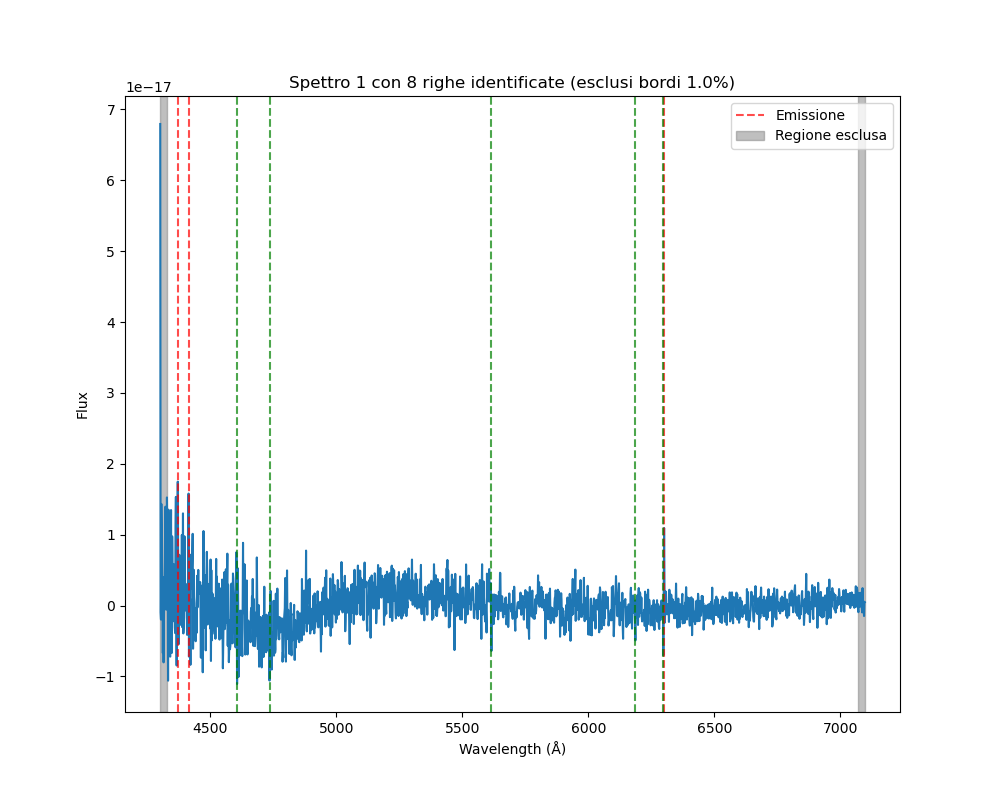

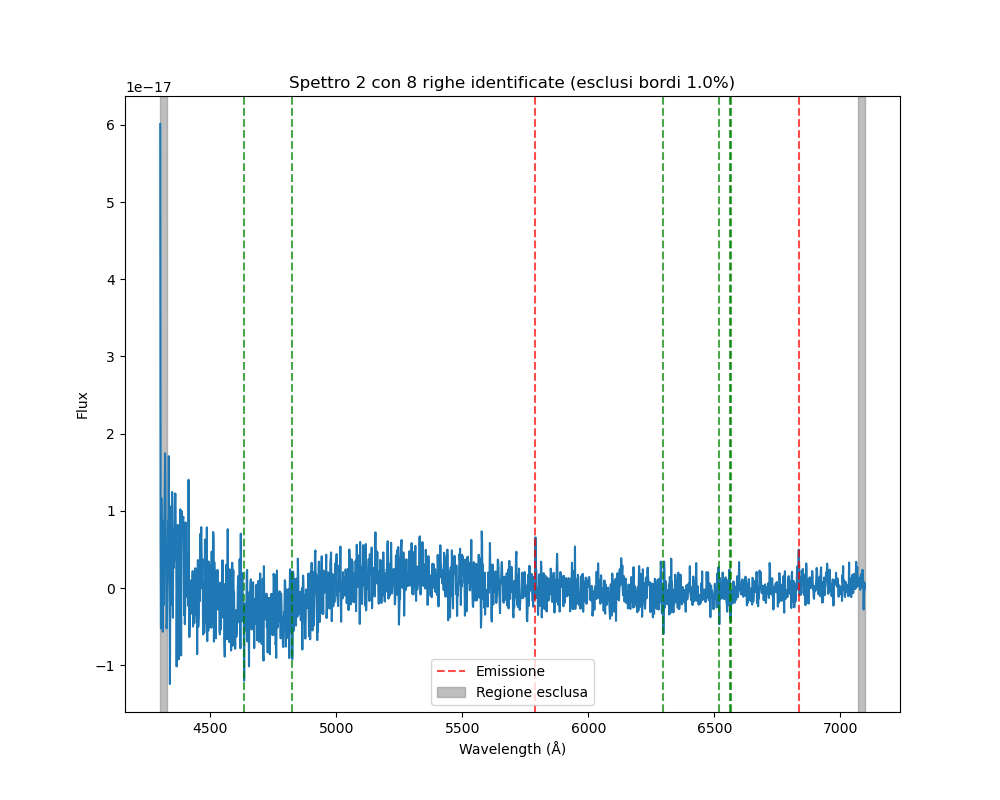

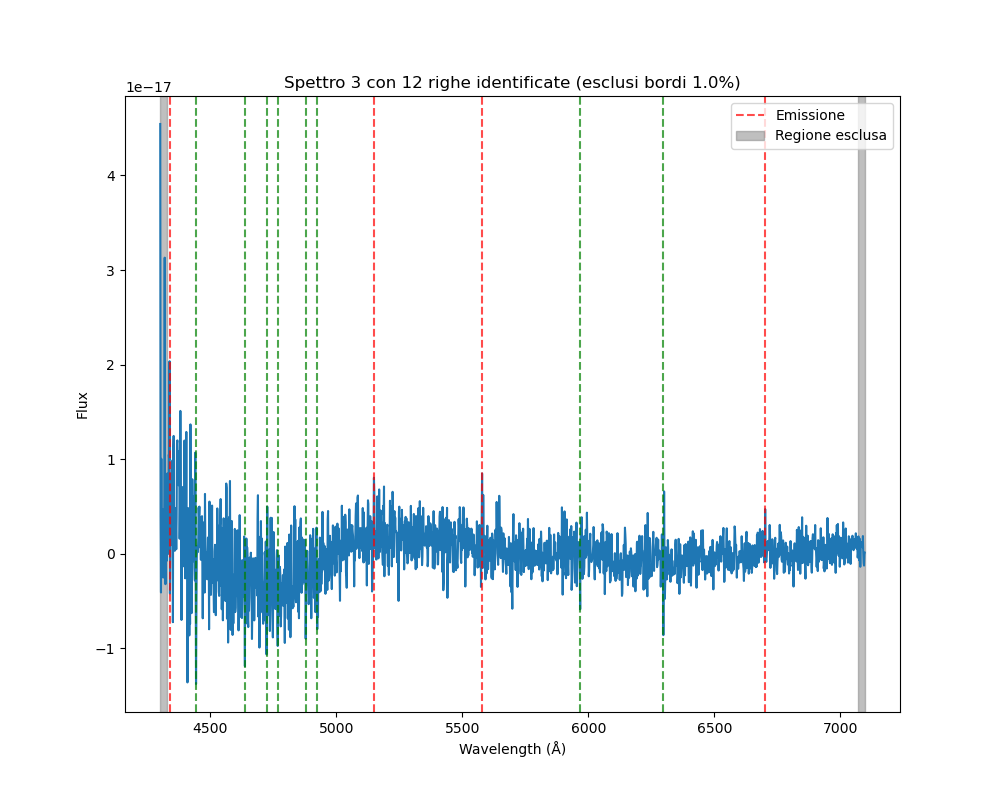

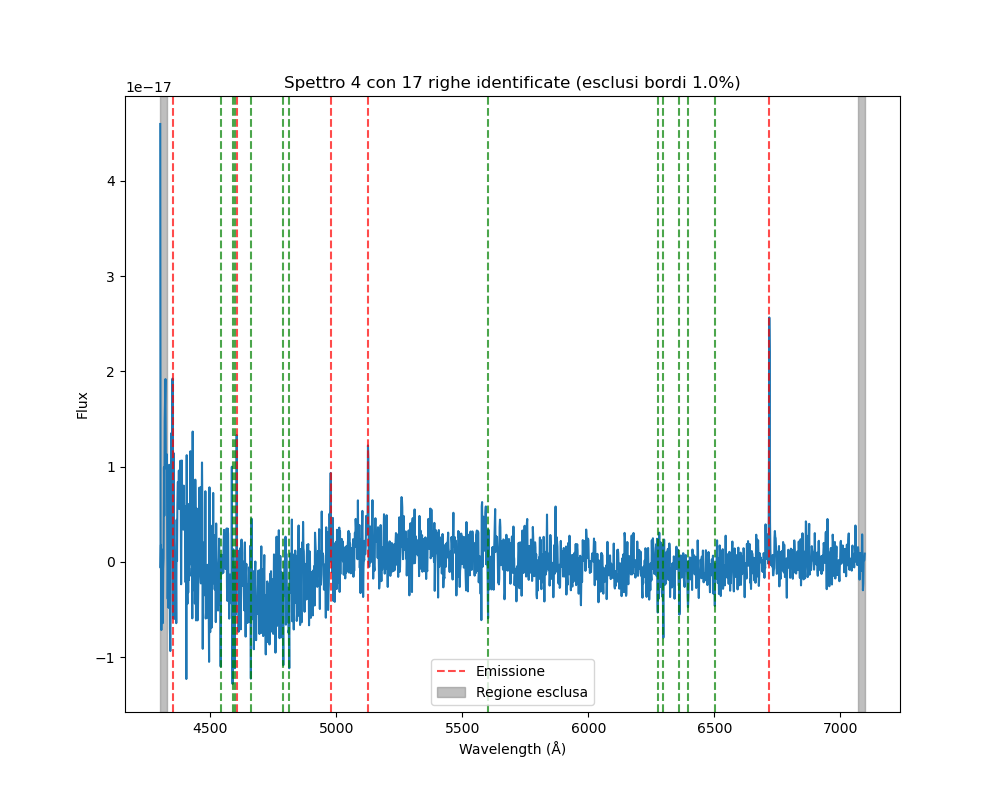

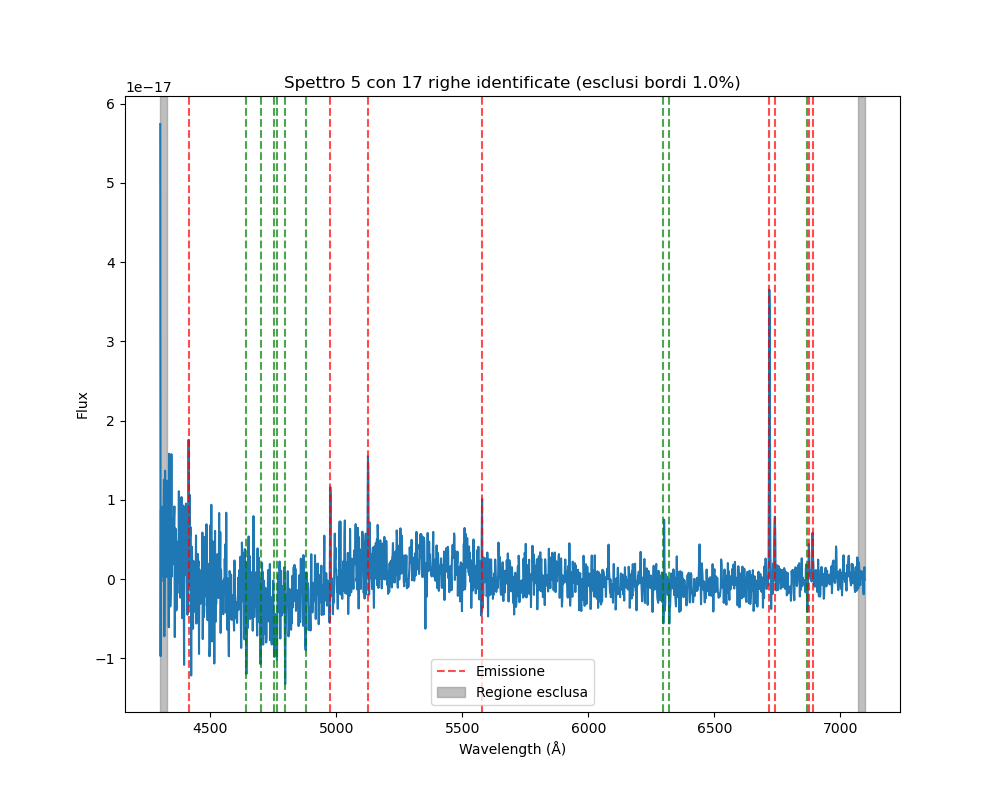

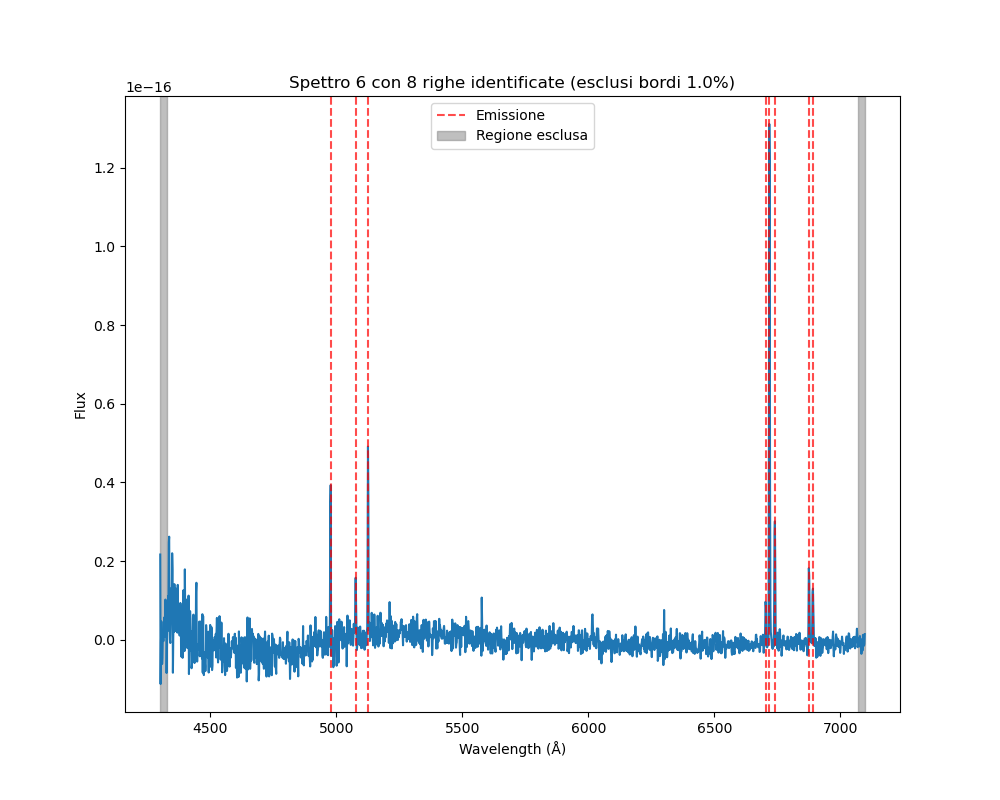

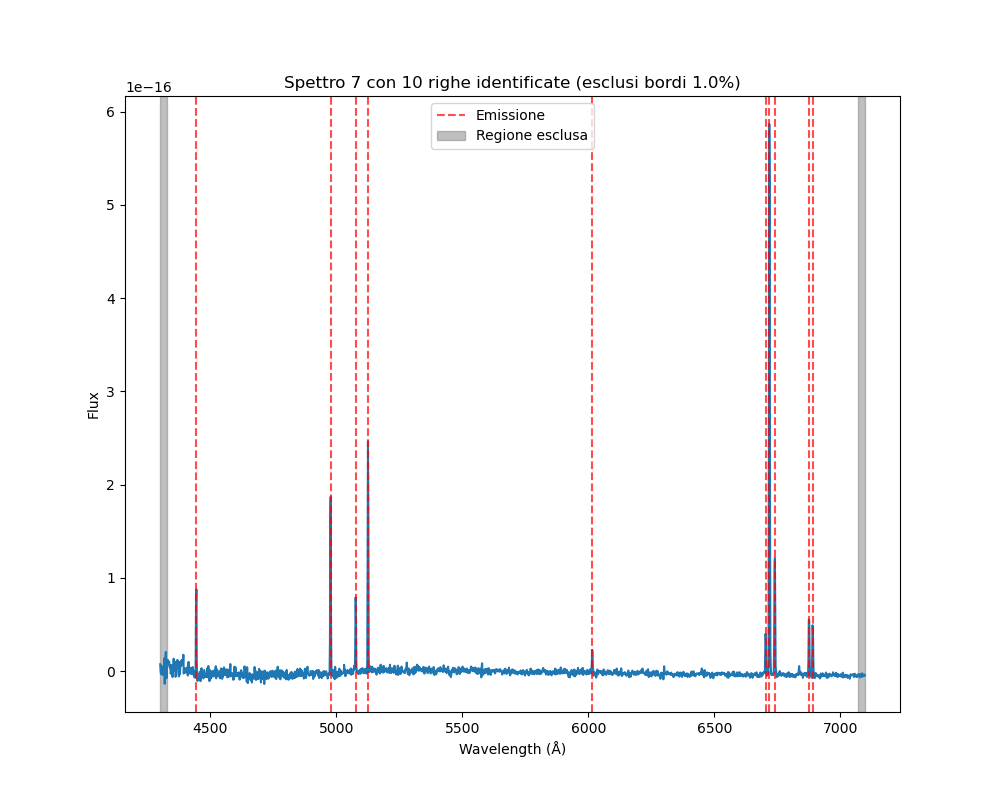

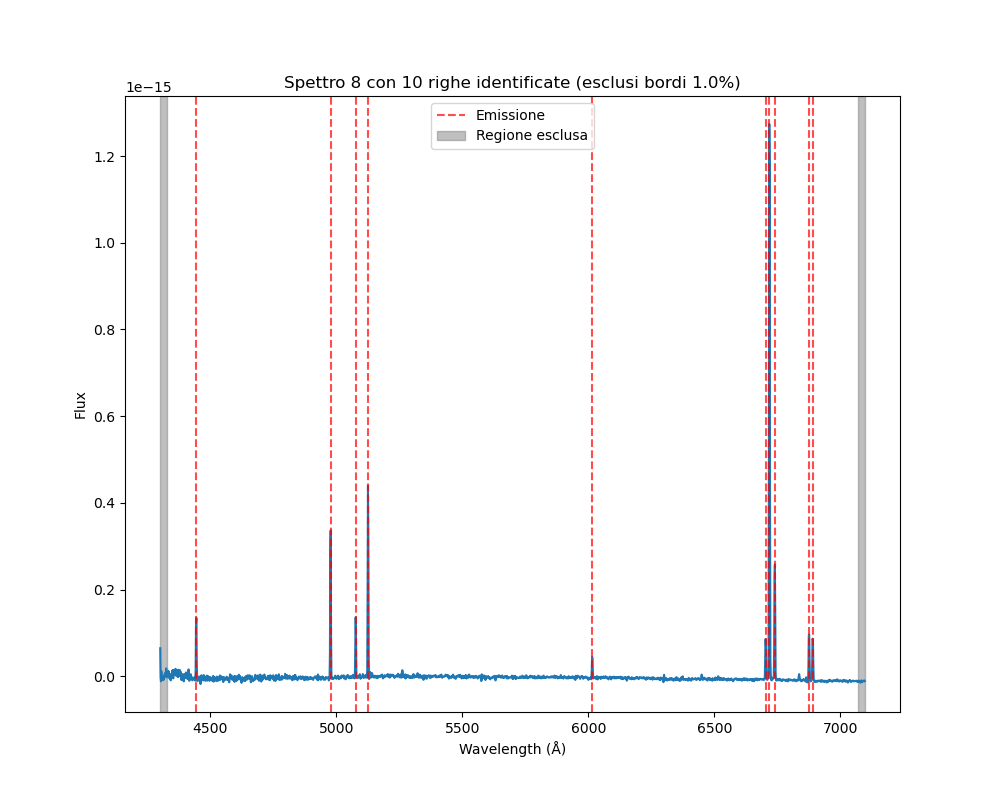

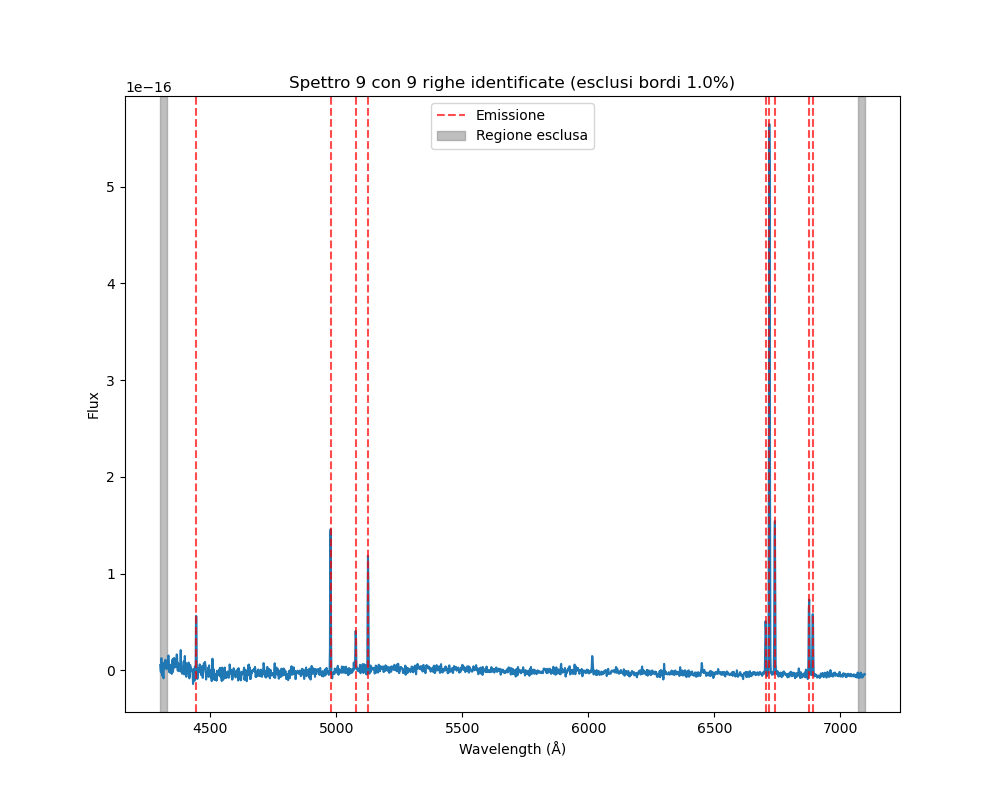

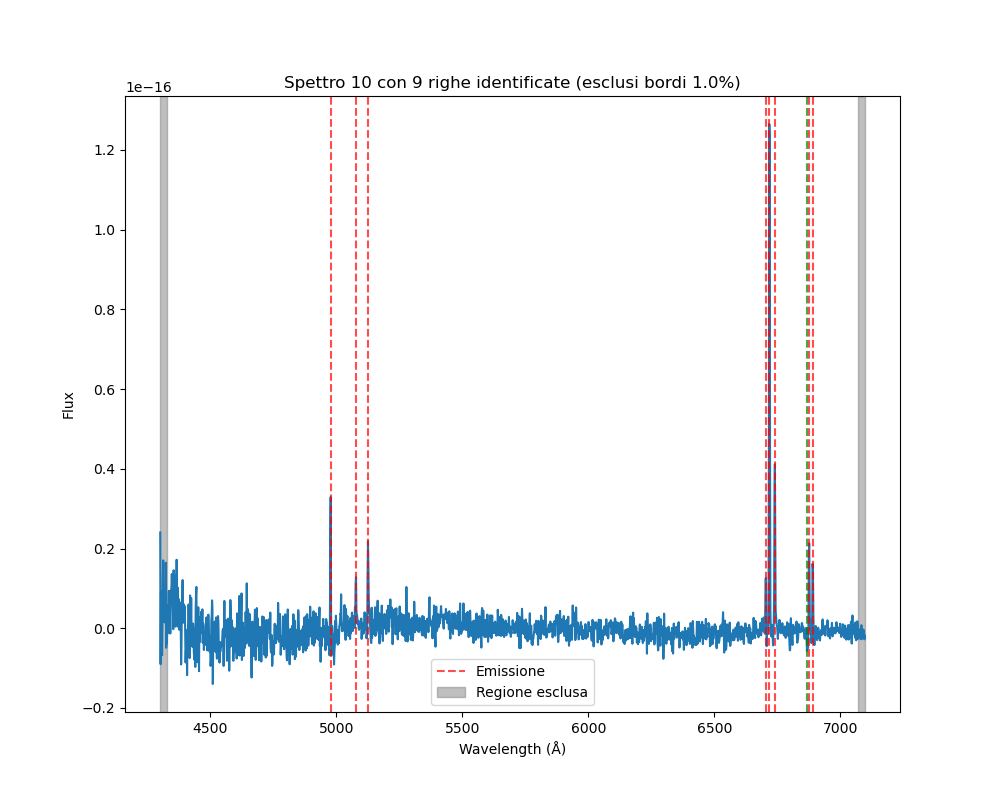

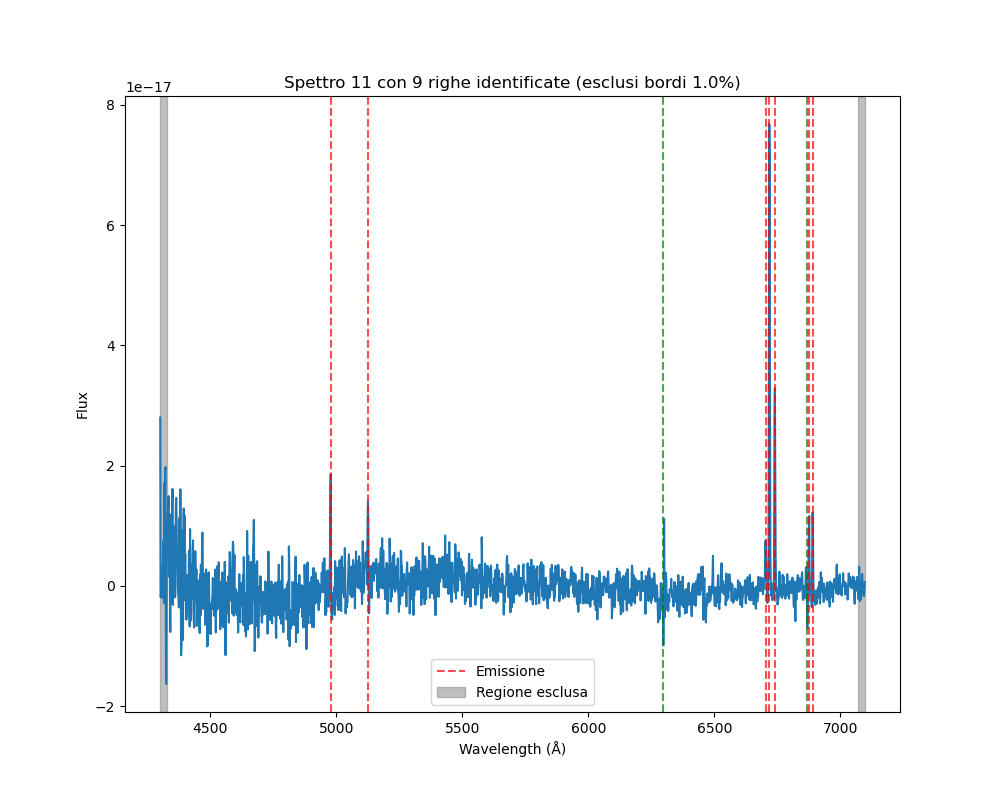

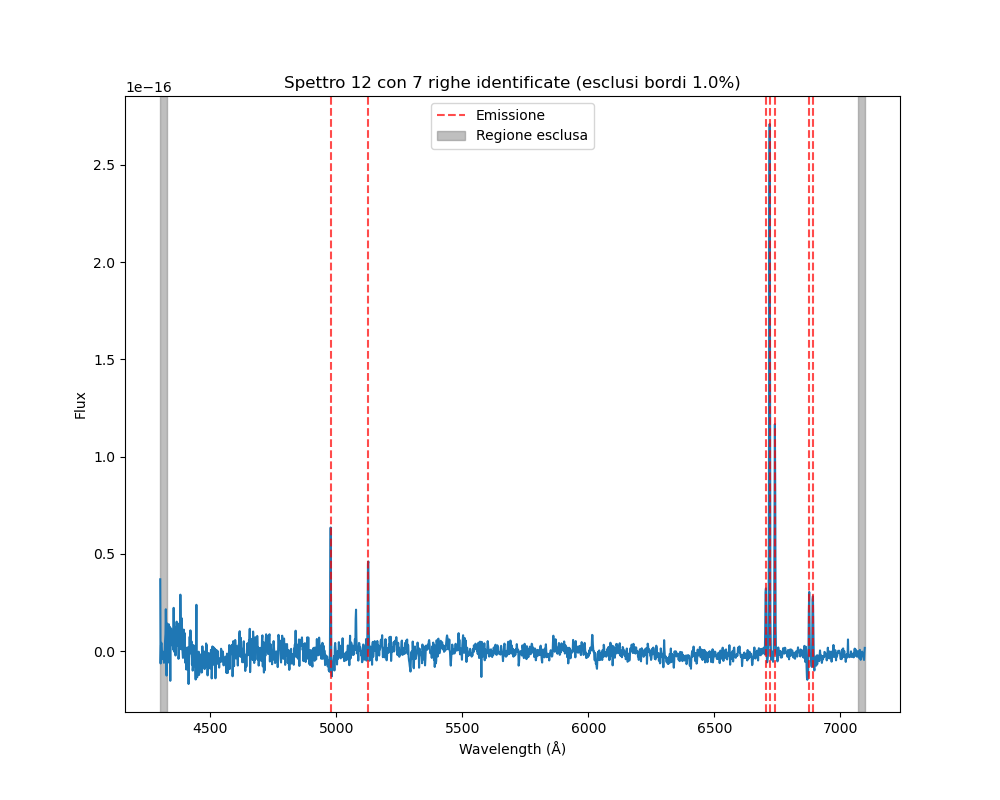

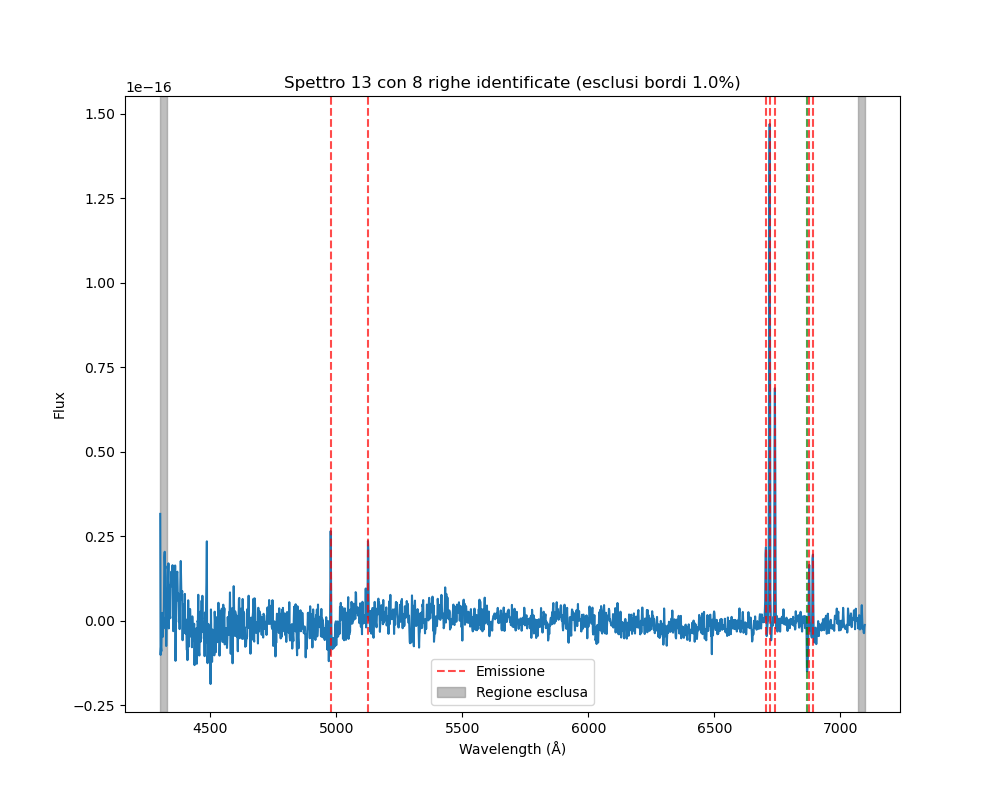

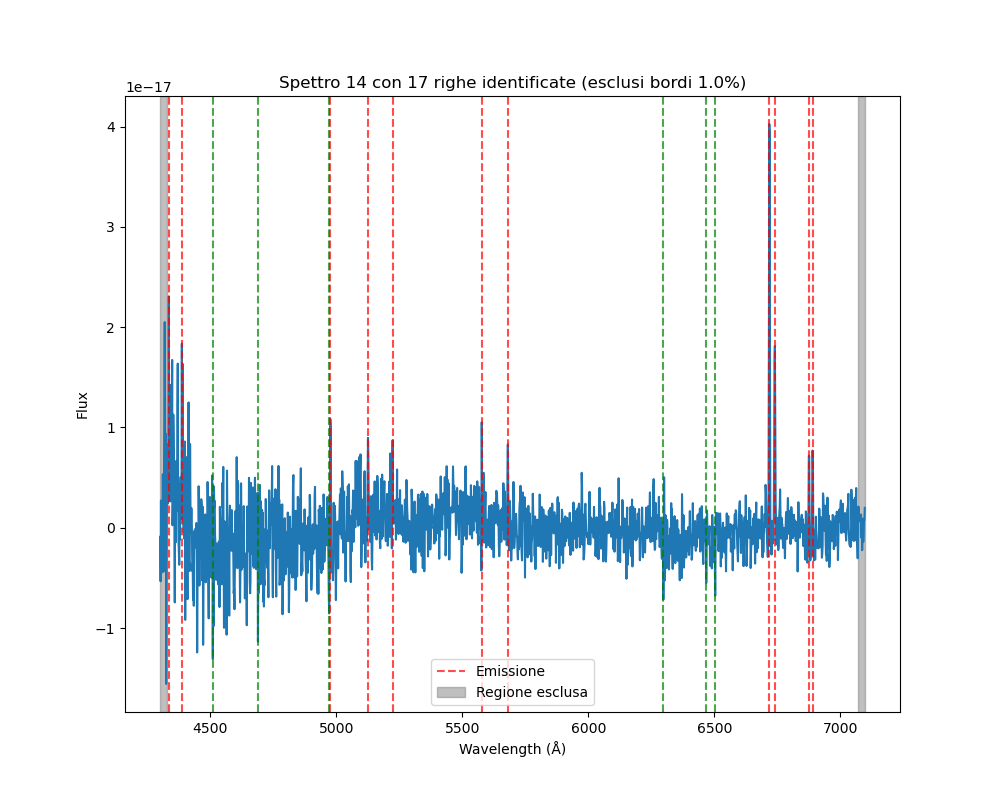

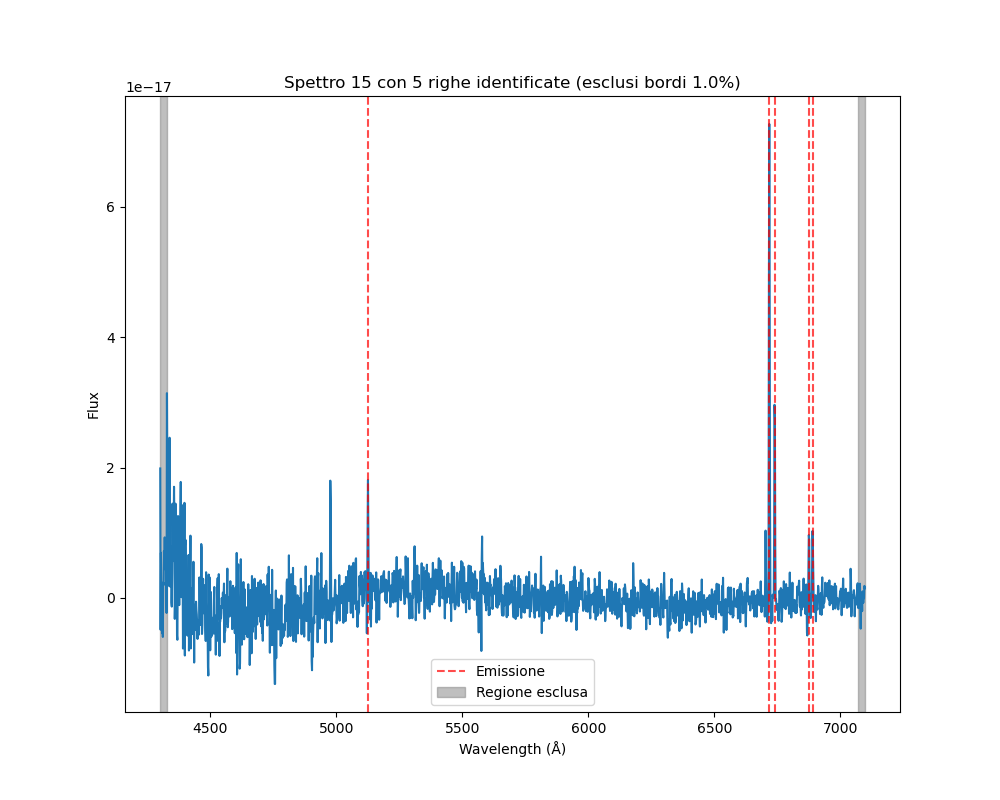

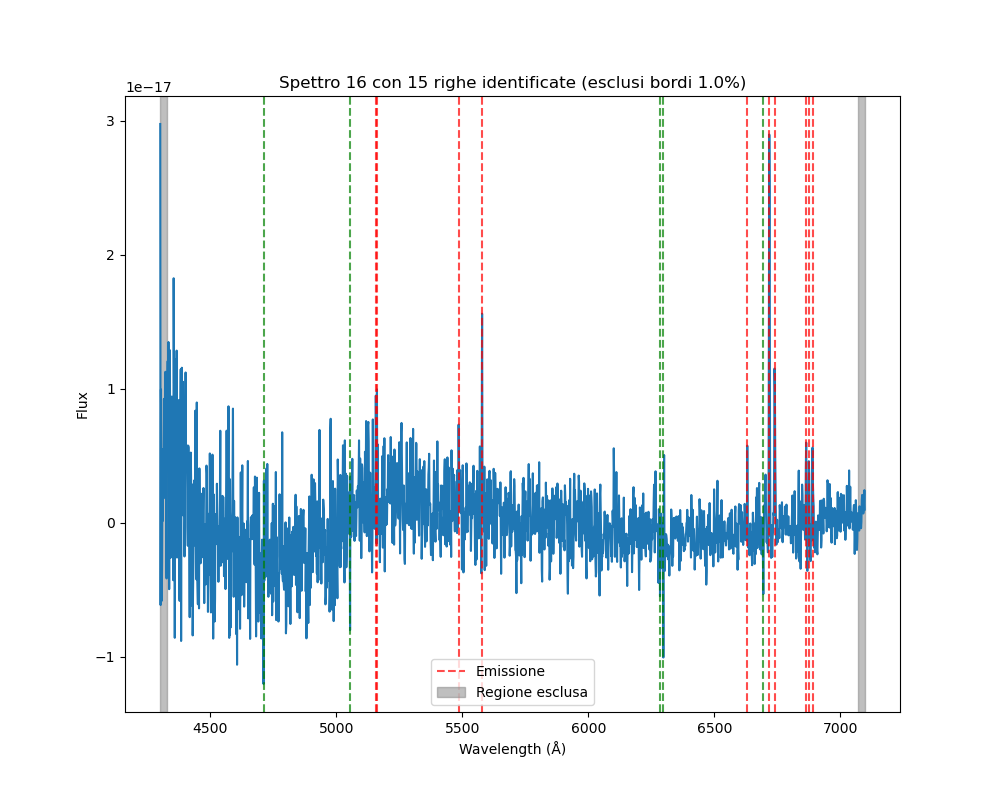

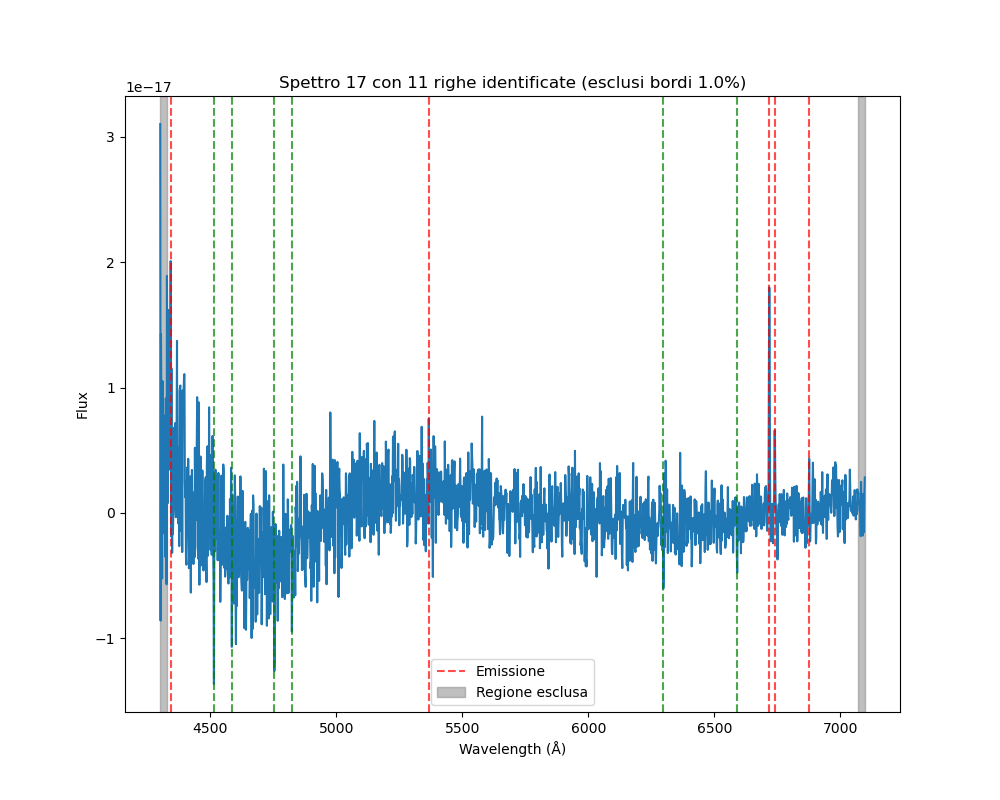

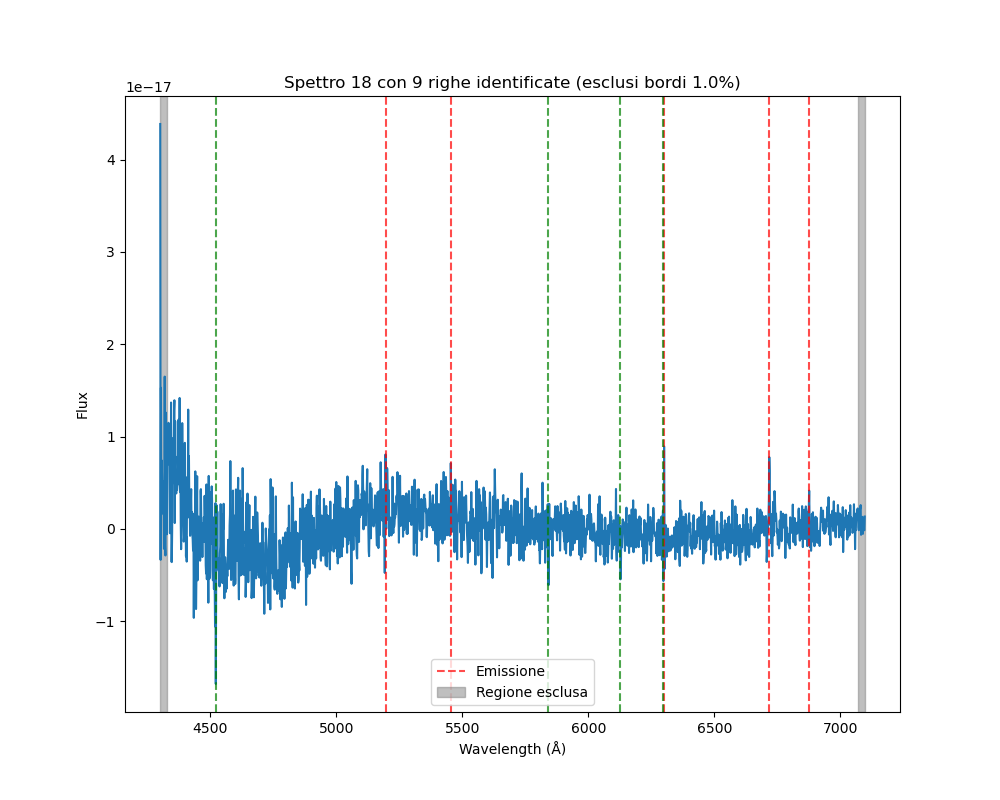

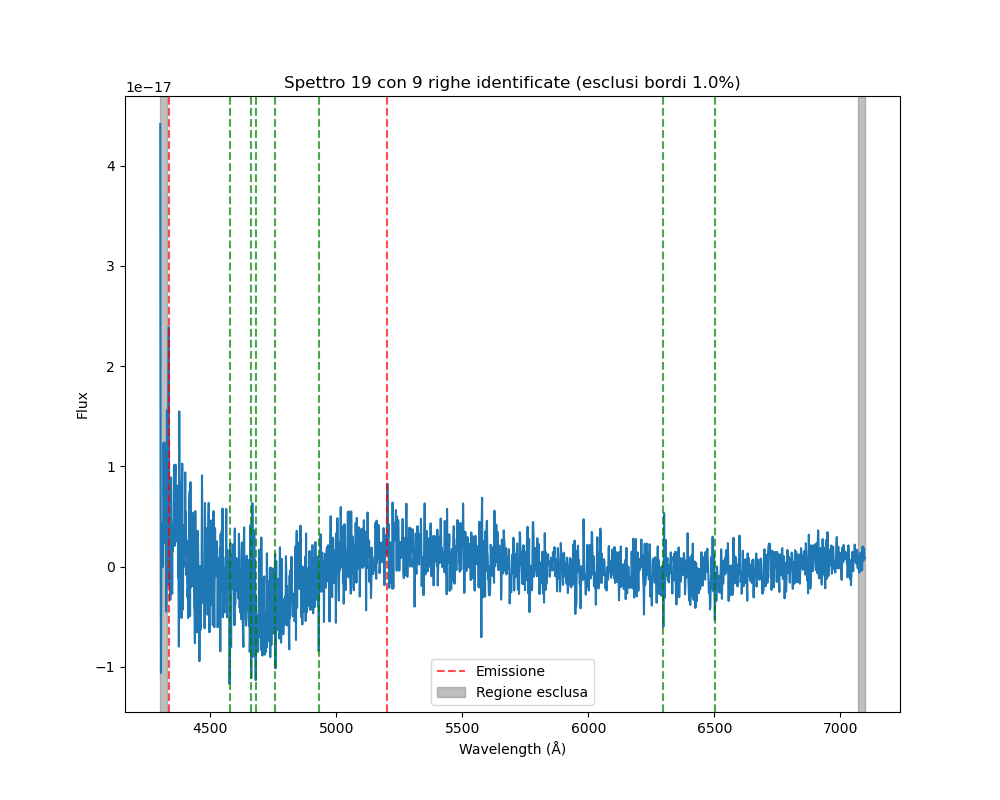

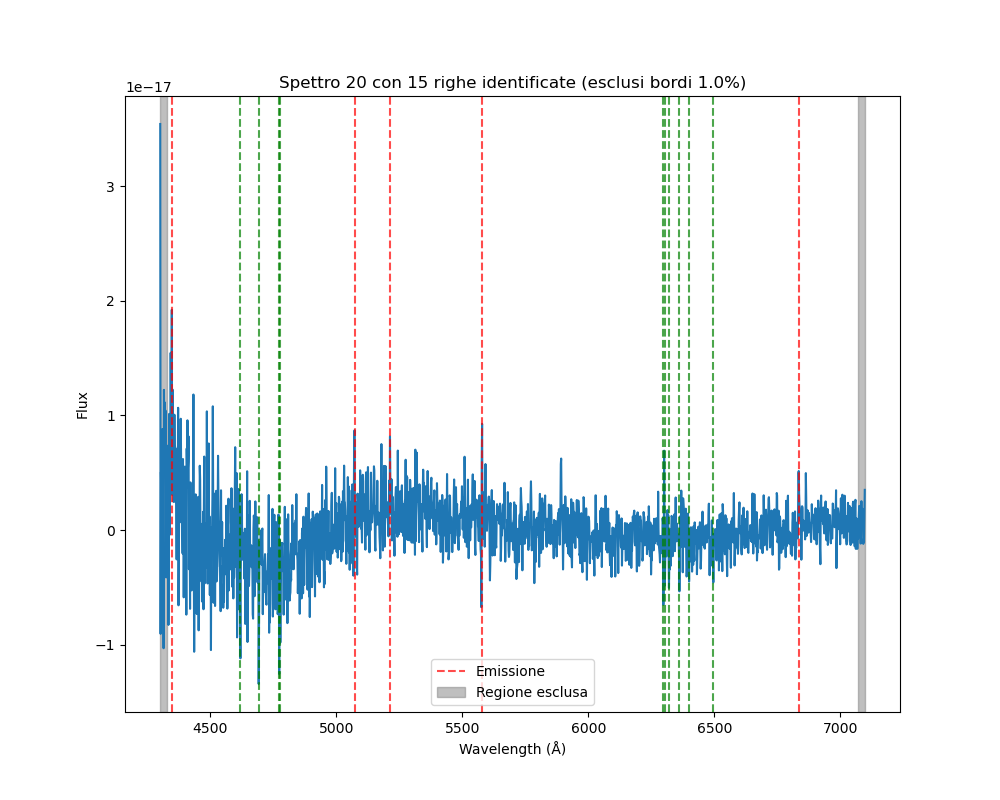

In [45]:
all_lines = []
noise_factor = [3, 3, 3, 3, 3, 4, 8, 13, 10, 4, 4, 9, 6, 3, 6, 3, 3, 3, 3, 3]

# Definisci la percentuale di spettro da escludere ai bordi (es. 5% per lato)
edge_fraction = 0.01
n_points = len(wv)
start_idx = int(n_points * edge_fraction)
end_idx = int(n_points * (1 - edge_fraction))

# Crea gli array ritagliati per la regione centrale
wv_central = wv[start_idx:end_idx]

for i in range(20):
    # Usa tutto lo spettro per il fitting del continuum
    spectrum = Spectrum(
        spectral_axis=wv * u.Angstrom,
        flux = spectra[i]* 1e-16 *u.erg / (u.cm**2 * u.s * u.Angstrom),  
        uncertainty = StdDevUncertainty(spectra_err[i]* 1e-16 *u.erg / (u.cm**2 * u.s * u.Angstrom))
    )
    g1_fit = fit_generic_continuum(spectrum, fitter=LinearLSQFitter())
    y_continuum_fitted = g1_fit(wv * u.Angstrom)
    #f, ax = plt.subplots(figsize = (10,8))
    #ax.plot(wv * u.Angstrom, spectra[i]* 1e-16*u.erg / (u.cm**2 * u.s * u.Angstrom))
    #ax.plot(wv * u.Angstrom, y_continuum_fitted)
    #ax.set_title("Continuum Fitting")
    
    flux_continuum_subtracted = spectrum.flux - y_continuum_fitted
    #f2, ax2 = plt.subplots(figsize = (10,8))
    #ax2.plot(wv * u.Angstrom, flux_continuum_subtracted)
    
    #ax2.set_title("Spectrum without continuum")
    
    # Crea lo spettro solo per la regione centrale (senza bordi)
    spectrum_no_continuum_central = Spectrum(
        spectral_axis=wv_central * u.Angstrom,
        flux=flux_continuum_subtracted[start_idx:end_idx],
        uncertainty=StdDevUncertainty(spectra_err[i][start_idx:end_idx] * 1e-16 * u.erg / (u.cm**2 * u.s * u.Angstrom))
    )
    
    # Trova le righe solo nella regione centrale
    lines = find_lines_threshold(spectrum_no_continuum_central, noise_factor = noise_factor[i])
    print('Spettro', i+1)
    print(f"Numero di righe trovate (regione centrale): {len(lines)}")
    print(lines)
    
    f3, ax3 = plt.subplots(figsize=(10,8))
    ax3.plot(wv, flux_continuum_subtracted.value)
    
    if len(lines) < 50:  # Solo se non sono troppe
        for line_pos in lines['line_center']:
            # Trova l'indice corrispondente nel flux per determinare il tipo di riga
            # Trova l'indice più vicino alla posizione della riga nell'array wv_central
            line_idx = np.argmin(np.abs(wv_central - line_pos.value))
            # Ottieni l'indice corrispondente nel flux completo
            flux_idx = start_idx + line_idx
            
            # Determina se è emissione (positiva) o assorbimento (negativa)
            if flux_continuum_subtracted[flux_idx].value > 0:
                # Riga di emissione - colore rosso
                ax3.axvline(x=line_pos.value, color='red', alpha=0.7, linestyle='--', 
                           label='Emissione' if line_pos == lines['line_center'][0] else "")
            else:
                # Riga di assorbimento - colore verde
                ax3.axvline(x=line_pos.value, color='green', alpha=0.7, linestyle='--',
                           label='Assorbimento' if line_pos == lines['line_center'][0] else "")

    # Aggiungi linee verticali per indicare i bordi esclusi
    ax3.axvspan(wv[0], wv[start_idx], alpha=0.5, color='gray', zorder=1, label='Regione esclusa')
    ax3.axvspan(wv[end_idx-1], wv[-1], alpha=0.5, color='gray', zorder=1)
    #ax3.axvline(x=wv[start_idx], color='gray', alpha=0.5, linestyle='-', linewidth=2, label='Regione esclusa')
    #ax3.axvline(x=wv[end_idx-1], color='gray', alpha=0.5, linestyle='-', linewidth=2)
    ax3.legend()
    
    ax3.set_title(f"Spettro {i+1} con {len(lines)} righe identificate (esclusi bordi {edge_fraction*100:.1f}%)")
    ax3.set_xlabel('Wavelength (Å)')
    ax3.set_ylabel('Flux')
    all_lines.append(lines)

In [59]:
#reference wv in air
l_Hgam = 4340.5
l_HA = 6562.8
l_HB = 4861.3
l_NII_1 = 6548.1
l_NII_2 = 6583.4
l_SII_1 = 6717.0
l_SII_2 = 6731.3
l_OIII_1 = 4958.9
l_OIII_2 = 5006.8
l_He_1 = 5875.6

lines_4 = [l_HB, l_OIII_2, l_HA] 
lines_5 = [l_HB, l_OIII_2, l_HA, l_NII_2,l_SII_1, l_SII_2]
lines_6 = [l_HB, l_OIII_1, l_OIII_2, l_NII_1, l_HA, l_NII_2, l_SII_1, l_SII_2] #10, 12
lines_7 = [l_Hgam, l_HB, l_OIII_1, l_OIII_2, l_He_1, l_NII_1, l_HA, l_NII_2, l_SII_1, l_SII_2] 
lines_8 = [l_Hgam, l_HB, l_OIII_1, l_OIII_2, l_He_1, l_NII_1, l_HA, l_NII_2, l_SII_1, l_SII_2] 
lines_9 = [l_Hgam, l_HB, l_OIII_1, l_OIII_2, l_NII_1, l_HA, l_NII_2, l_SII_1, l_SII_2]
lines_10 = [l_HB, l_OIII_1, l_OIII_2, l_NII_1, l_HA, l_NII_2, l_SII_1, l_SII_2]
lines_11 = [l_HB, l_OIII_2, l_NII_1, l_HA, l_NII_2,l_SII_1, l_SII_2] #, 13
lines_12 = [l_HB, l_OIII_2, l_NII_1, l_HA, l_NII_2, l_SII_1, l_SII_2]
lines_13 = [l_HB, l_OIII_2, l_NII_1, l_HA, l_NII_2,l_SII_1, l_SII_2]
lines_14 = [l_HA, l_NII_2,l_SII_1, l_SII_2]
lines_15 = [l_OIII_2, l_HA, l_NII_2, l_SII_1, l_SII_2]
lines_16 = [l_HA, l_NII_2, l_SII_1, l_SII_2]
lines_17 = [l_HA, l_NII_2, l_SII_1] 
lines_18 = [l_HA, l_NII_2, l_SII_1] 

lines_spectrum_4 = [4977.1, 5125.1, 6717.58]
lines_spectrum_5 = [4976.62, 5125.1, 6717.58, 6739.78, 6874.46, 6889.26]
lines_spectrum_6 = all_lines[5]['line_center'] 
lines_spectrum_7 = all_lines[6]['line_center']
lines_spectrum_8 = all_lines[7]['line_center']
lines_spectrum_9 = all_lines[8]['line_center']
lines_spectrum_10 = all_lines[9]['line_center']
lines_spectrum_11 = all_lines[10]['line_center'] 
lines_spectrum_12 = all_lines[11]['line_center']
lines_spectrum_13 = all_lines[12]['line_center']
lines_spectrum_14 = [6717.579999999287, 6739.77999999928, 6874.459999999241, 6889.259999999236]
lines_spectrum_15 = all_lines[14]['line_center']
lines_spectrum_16 = [6717.58, 6738.3, 6874.46, 6889.26]
lines_spectrum_17 =[6717.58, 6739.78, 6875.93]
lines_spectrum_18 =[6717.5, 6738.0, 6875.7]

def redshift(lines, lines_spectrum):
    z = np.zeros(len(lines))
    for i in range(len(lines)):
        z[i] = lines_spectrum[i].value / lines[i] - 1
    z_mean = np.mean(z)
    z_std = np.std(z)
    return z_mean, z_std
    
def redshift_hand(lines, lines_spectrum):
    z = np.zeros(len(lines))
    for i in range(len(lines)):
        z[i] = lines_spectrum[i]/ lines[i] - 1
    z_mean = np.mean(z)
    z_std = np.std(z)
    return z_mean, z_std
    
z_4_mean, z_4_std = redshift_hand(lines_4, lines_spectrum_4)
z_5_mean, z_5_std = redshift_hand(lines_5, lines_spectrum_5) 
z_6_mean, z_6_std = redshift(lines_6, lines_spectrum_6) 
z_7_mean, z_7_std = redshift(lines_7, lines_spectrum_7) 
z_8_mean, z_8_std = redshift(lines_8, lines_spectrum_8) 
z_9_mean, z_9_std = redshift(lines_9, lines_spectrum_9) 
z_10_mean, z_10_std = redshift(lines_10, lines_spectrum_10) 
z_11_mean, z_11_std = redshift(lines_11, lines_spectrum_11) 
z_12_mean, z_12_std = redshift(lines_12, lines_spectrum_12) 
z_13_mean, z_13_std = redshift(lines_13, lines_spectrum_13) 
z_14_mean, z_14_std = redshift_hand(lines_14, lines_spectrum_14) 
z_15_mean, z_15_std = redshift(lines_15, lines_spectrum_15)
z_16_mean, z_16_std = redshift_hand(lines_16, lines_spectrum_16) 
z_17_mean, z_17_std = redshift_hand(lines_17, lines_spectrum_17) 
z_18_mean, z_18_std = redshift_hand(lines_18, lines_spectrum_18) 

z = [np.nan, np.nan, np.nan, z_4_mean, z_5_mean, z_6_mean, z_7_mean, z_8_mean, z_9_mean, z_10_mean, z_11_mean, z_12_mean, z_13_mean, z_14_mean, z_15_mean, z_16_mean, z_17_mean, z_18_mean, np.nan, np.nan]
z_err = [np.nan, np.nan, np.nan, z_4_std, z_5_std, z_6_std, z_7_std, z_8_std, z_9_std, z_10_std, z_11_std, z_12_std, z_13_std, z_14_std, z_15_std, z_16_std, z_17_std, z_18_std, np.nan, np.nan]

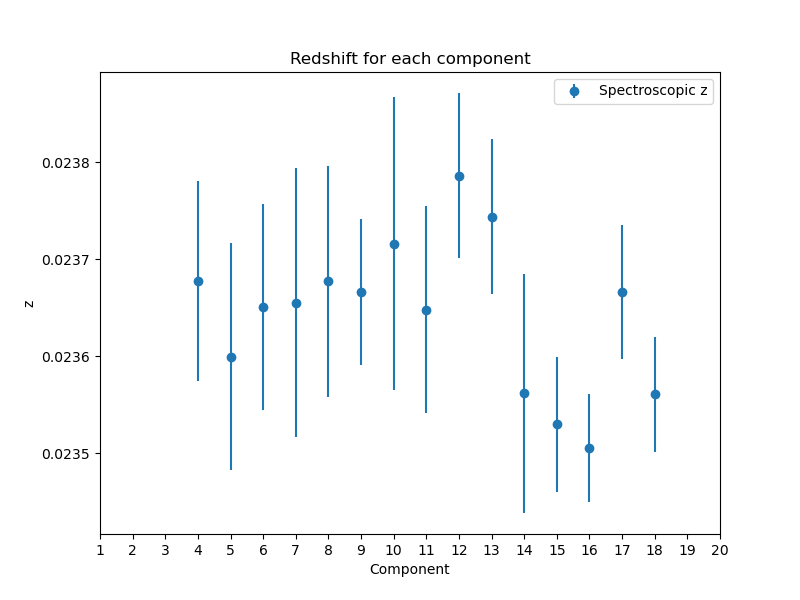

In [60]:
plt.figure(figsize=(8, 6))
comp = np.arange(1, 21, 1)
plt.errorbar(comp, z, z_err, ls='none', marker = 'o', label = 'Spectroscopic z')
plt.xlabel('Component')
plt.ylabel('z')
plt.xticks(comp)
#plt.axhline(0.01505 , color = 'red', label = 'Tabulated z')
plt.title('Redshift for each component')
plt.legend()
plt.savefig('Redshift_grad', bbox_inches='tight')

red_table = np.column_stack((z, z_err))
np.savetxt('redshift_grad.txt', red_table, header='redshift redshift_error', fmt='%.5f',delimiter='\t')

## S/N emission lines 

In [61]:
def SNR_line(wv, wv_line, spectrum): 
    left_region = (wv > wv_line-15)*(wv < wv_line-5) 
    right_region = (wv > wv_line+5)*(wv < wv_line+15) 
    clean_mask = left_region | right_region

    mask = (wv > wv_line-4)*(wv < wv_line+4)
    wv_bin = np.array(np.where(mask == True))
    flux = spectrum[mask] - np.mean(spectrum[clean_mask])
    signal = (np.trapz(flux, wv[mask]))
    noise = np.std(spectrum[clean_mask] - np.mean(spectrum[clean_mask]))*1.48*np.sqrt(wv_bin.shape[1]) #std*delta(wv)*number of A under the line
    SNR = signal/noise
    return SNR, signal, noise
    
def SNR_OIII_line(wv, OIII_1, OIII_2, wv_line, spectrum):
    
    left_region = (wv > OIII_1-15)*(wv < OIII_1-5) 
    right_region = (wv > OIII_2+5)*(wv < OIII_2+15) 
    clean_mask = left_region | right_region
    
    mask = (wv > wv_line-4)*(wv < wv_line+4)
    wv_bin = np.array(np.where(mask == True))
    flux = spectra[i, mask] - np.mean(spectrum[clean_mask])
    signal = (np.trapz(flux, wv[mask]))
    noise = np.std(spectrum[clean_mask] - np.mean(spectrum[clean_mask]))*1.48*np.sqrt(wv_bin.shape[1]) #std*delta(wv)*number of A under the line
    SNR = signal/noise
    return SNR, signal, noise 
    
def SNR_SII_line(wv, SII_1, SII_2, wv_line, spectrum):
    
    left_region = (wv > SII_1-15)*(wv < SII_1-5) 
    right_region = (wv > SII_2+5)*(wv < SII_2+15) 
    clean_mask = left_region | right_region
    
    mask = (wv > wv_line-4)*(wv < wv_line+4)
    wv_bin = np.array(np.where(mask == True))
    flux = spectra[i, mask] - np.mean(spectrum[clean_mask])
    signal = (np.trapz(flux, wv[mask]))
    noise = np.std(spectrum[clean_mask] - np.mean(spectrum[clean_mask]))*1.48*np.sqrt(wv_bin.shape[1]) #std*delta(wv)*number of A under the line
    SNR = signal/noise
    return SNR, signal, noise 

def SNR_HA_NII(wv, NII_1, NII_2, wv_line, spectrum):
    
    left_region = (wv > NII_1-15)*(wv < NII_1-5) 
    right_region = (wv > NII_2+5)*(wv < NII_2+15) 
    clean_mask = left_region | right_region
    
    mask = (wv > wv_line-4)*(wv < wv_line+4)
    wv_bin = np.array(np.where(mask == True))
    flux = spectra[i, mask] - np.mean(spectrum[clean_mask])
    signal = (np.trapz(flux, wv[mask]))
    noise = np.std(spectrum[clean_mask] - np.mean(spectrum[clean_mask]))*1.48*np.sqrt(wv_bin.shape[1]) #std*delta(wv)*number of A under the line
    SNR = signal/noise
    return SNR, signal, noise 

def save_spectral_data(snr, signal, noise, line_name, output_dir='20ext', num_spectra=20):
    
    data = np.concatenate([
        np.array(snr).reshape(-1, 1),
        np.array(signal).reshape(-1, 1),
        np.array(noise).reshape(-1, 1)
    ], axis=1)

    df = pd.DataFrame(
        data, 
        columns=['SNR', 'Signal', 'Noise'],
        index=[f'Spettro_{i+1}' for i in range(num_spectra)]
    )
    
    df_path = os.path.join(output_dir, f'SNR_{line_name}.csv')
    df.to_csv(df_path, float_format='%.3f')
    print(df)
    return df_path

In [62]:
SNR_HB = np.zeros(20)
signal_HB = np.zeros(20)
noise_HB = np.zeros(20)
SNR_SII_1 = np.zeros(20)
signal_SII_1 = np.zeros(20)
noise_SII_1 = np.zeros(20)
SNR_SII_2 = np.zeros(20)
signal_SII_2 = np.zeros(20)
noise_SII_2 = np.zeros(20)
SNR_NII_1 = np.zeros(20)
signal_NII_1 = np.zeros(20)
noise_NII_1 = np.zeros(20)
SNR_NII_2 = np.zeros(20)
signal_NII_2 = np.zeros(20)
noise_NII_2 = np.zeros(20)
SNR_HA = np.zeros(20)
signal_HA = np.zeros(20)
noise_HA = np.zeros(20)
SNR_OIII_1 = np.zeros(20)
signal_OIII_1 = np.zeros(20)
noise_OIII_1 = np.zeros(20)
SNR_OIII_2 = np.zeros(20)
signal_OIII_2 = np.zeros(20)
noise_OIII_2 = np.zeros(20)

for i in range(20):
    if np.isnan(z[i]) == False: 
        l_Hgam = 4340.5*(1+z[i])
        l_HA = 6562.8*(1+z[i])
        l_HB = 4861.3*(1+z[i])
        l_NII_1 = 6548.1*(1+z[i])
        l_NII_2 = 6583.4*(1+z[i])
        l_SII_1 = 6717.0*(1+z[i])
        l_SII_2 = 6731.3*(1+z[i])
        l_OIII_1 = 4958.9*(1+z[i])
        l_OIII_2 = 5006.8*(1+z[i])
        l_He_1 = 5875.6*(1+z[i])
        SNR_HB[i], signal_HB[i], noise_HB[i] = SNR_line(wv, l_HB, spectra[i])
        SNR_SII_1[i], signal_SII_1[i], noise_SII_1[i] = SNR_SII_line(wv, l_SII_1, l_SII_2, l_SII_1, spectra[i])
        SNR_SII_2[i], signal_SII_2[i], noise_SII_2[i] = SNR_SII_line(wv, l_SII_1, l_SII_2, l_SII_2, spectra[i])
        SNR_NII_1[i], signal_NII_1[i], noise_NII_1[i] = SNR_HA_NII(wv, l_NII_1, l_NII_2, l_NII_1, spectra[i])
        SNR_NII_2[i], signal_NII_2[i], noise_NII_2[i] = SNR_HA_NII(wv, l_NII_1, l_NII_2, l_NII_2, spectra[i])
        SNR_HA[i], signal_HA[i], noise_HA[i] = SNR_HA_NII(wv, l_NII_1, l_NII_2, l_HA, spectra[i])
        SNR_OIII_1[i], signal_OIII_1[i], noise_OIII_1[i] = SNR_OIII_line(wv, l_OIII_1, l_OIII_2, l_OIII_1, spectra[i])
        SNR_OIII_2[i], signal_OIII_2[i], noise_OIII_2[i] = SNR_OIII_line(wv, l_OIII_1, l_OIII_2, l_OIII_2, spectra[i])
    else:
        SNR_HB[i] = np.nan
        signal_HB[i] = np.nan
        noise_HB[i] = np.nan
        SNR_SII_1[i] = np.nan 
        signal_SII_1[i] = np.nan 
        noise_SII_1[i] = np.nan 
        SNR_SII_2[i] = np.nan 
        signal_SII_2[i] = np.nan 
        noise_SII_2[i] = np.nan 
        SNR_NII_1[i] = np.nan 
        signal_NII_1[i] = np.nan 
        noise_NII_1[i] = np.nan 
        SNR_NII_2[i] = np.nan 
        signal_NII_2[i] = np.nan 
        noise_NII_2[i] = np.nan 
        SNR_HA[i] = np.nan 
        signal_HA[i] = np.nan 
        noise_HA[i] = np.nan 
        SNR_OIII_1[i] = np.nan 
        signal_OIII_1[i] = np.nan 
        noise_OIII_1[i] = np.nan 
        SNR_OIII_2[i] = np.nan 
        signal_OIII_2[i] = np.nan
        noise_OIII_2[i] = np.nan
        
save_spectral_data(SNR_HB, signal_HB, noise_HB, 'HB')
save_spectral_data(SNR_SII_1, signal_SII_1, noise_SII_1, 'SII_1')
save_spectral_data(SNR_SII_2, signal_SII_2, noise_SII_2, 'SII_2')
save_spectral_data(SNR_NII_1, signal_NII_1, noise_NII_1, 'NII_1')
save_spectral_data(SNR_NII_2, signal_NII_2, noise_NII_2, 'NII_2')
save_spectral_data(SNR_HA, signal_HA, noise_HA, 'HA')
save_spectral_data(SNR_OIII_1, signal_OIII_1, noise_OIII_1, 'OIII_1')
save_spectral_data(SNR_OIII_2, signal_OIII_2, noise_OIII_2, 'OIII_2')

                   SNR     Signal     Noise
Spettro_1          NaN        NaN       NaN
Spettro_2          NaN        NaN       NaN
Spettro_3          NaN        NaN       NaN
Spettro_4     3.206170   0.340433  0.106181
Spettro_5    11.394679   0.454198  0.039861
Spettro_6    12.001635   1.321430  0.110104
Spettro_7    64.456896   6.559672  0.101768
Spettro_8   168.430317  11.619636  0.068988
Spettro_9    73.539905   5.224758  0.071047
Spettro_10   10.646867   1.005891  0.094478
Spettro_11    7.682297   0.629181  0.081900
Spettro_12   26.547999   2.101881  0.079173
Spettro_13    9.932915   0.997549  0.100429
Spettro_14    4.422195   0.409457  0.092591
Spettro_15   16.750027   0.612241  0.036552
Spettro_16    2.695499   0.238553  0.088501
Spettro_17    2.218769   0.144242  0.065010
Spettro_18   -1.160968  -0.064836  0.055847
Spettro_19         NaN        NaN       NaN
Spettro_20         NaN        NaN       NaN
                  SNR    Signal     Noise
Spettro_1         NaN       NaN   

'20ext\\SNR_OIII_2.csv'

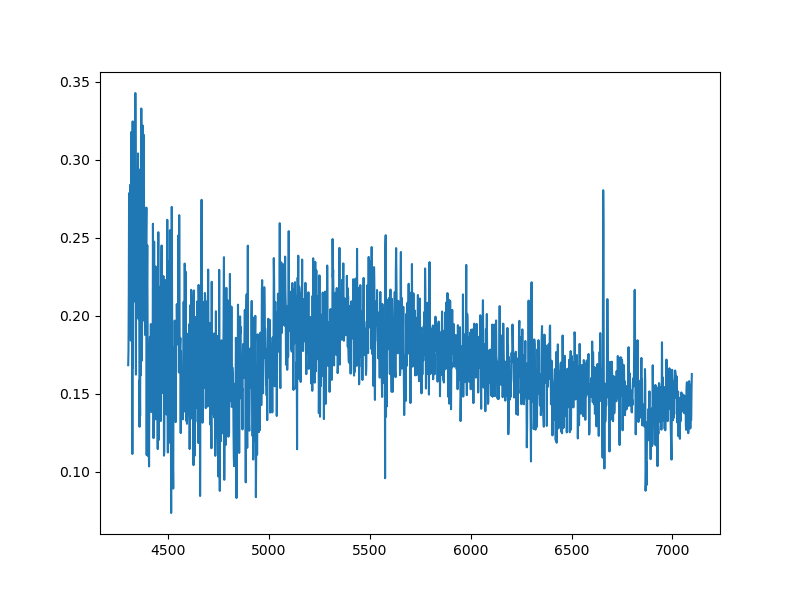

In [48]:
plt.figure(figsize = (8, 6))
plt.plot(wv, spectra[12])

In [47]:
l_OIII_2

5078.661538806257